# CIFAR-10 Image Classification — CNN + Streamlit App

This notebook builds a Convolutional Neural Network (CNN) to classify images into 10 categories: **airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck**.

Steps covered:
1. Load and normalize the CIFAR-10 dataset
2. Design a CNN architecture
3. Train the model (with early stopping & checkpointing)
4. Evaluate the model (accuracy, loss curves, confusion matrix, classification report)
5. Save the trained model + class names for use in a Streamlit app


In [1]:
!pip install -q tensorflow streamlit pillow numpy matplotlib scikit-learn seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 1. Load & Normalize the Data

In [3]:
# CIFAR-10 class names (index order matches the dataset's integer labels)
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]


In [4]:
# Load CIFAR-10 dataset (60,000 32x32 color images, 10 classes)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Labels come back as shape (N, 1) -> flatten to (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape: ", x_test.shape, y_test.shape)


Train shape: (50000, 32, 32, 3) (50000,)
Test shape:  (10000, 32, 32, 3) (10000,)


In [5]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


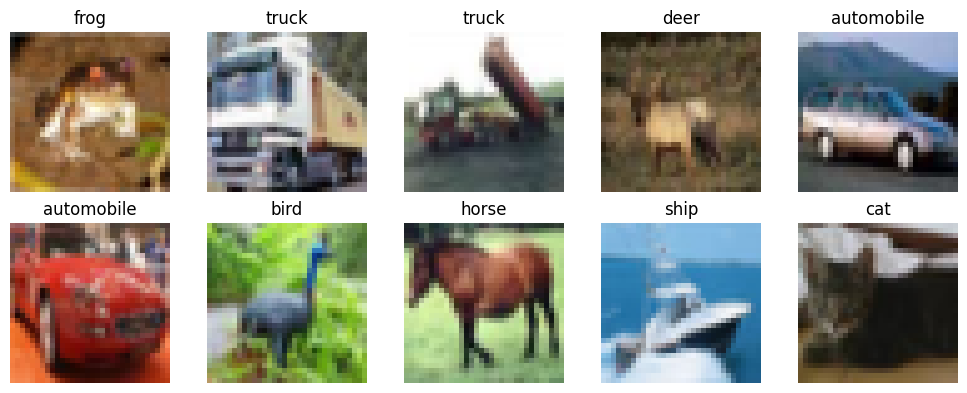

In [6]:
# Peek at a few training images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


## 2. Data Augmentation (optional but improves generalization)

Small random flips/shifts help the model generalize better and reduce overfitting.

In [7]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="data_augmentation")


## 3. Build the CNN Architecture

In [8]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,57

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

## 4. Compile & Train

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "cifar10_cnn_best.keras", monitor="val_accuracy", save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
    ),
]


In [10]:
EPOCHS = 10       # EarlyStopping will usually stop well before this
BATCH_SIZE = 64

history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=callbacks,
)


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 70ms/step - accuracy: 0.3901 - loss: 1.8167 - val_accuracy: 0.4632 - val_loss: 1.5009 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.5235 - loss: 1.3222 - val_accuracy: 0.4810 - val_loss: 1.5876 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 138ms/step - accuracy: 0.5832 - loss: 1.1648 - val_accuracy: 0.5892 - val_loss: 1.1695 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.6257 - loss: 1.0609 - val_accuracy: 0.6811 - val_loss: 0.8973 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 105ms/step - accuracy: 0.6500 - loss: 0.9947 - val_accuracy: 0.6538 - val_loss: 1.0090 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.6726 - loss: 0.9318 - val_accuracy: 0.7327 - val_loss: 0.7694 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 193ms/step - accuracy: 0.690

## 5. Evaluate the Model

In [15]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


313/313 - 4s - 14ms/step - accuracy: 0.8207 - loss: 0.5365
Test Loss: 0.5365
Test Accuracy: 0.8207


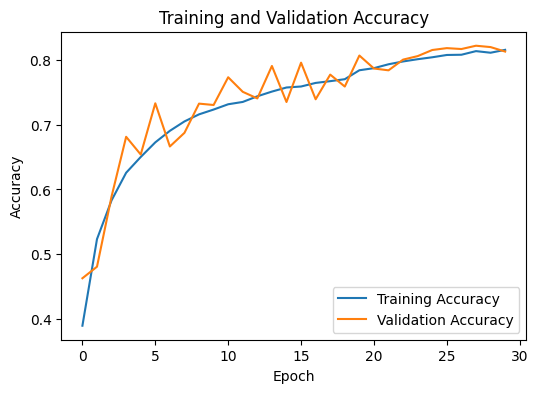

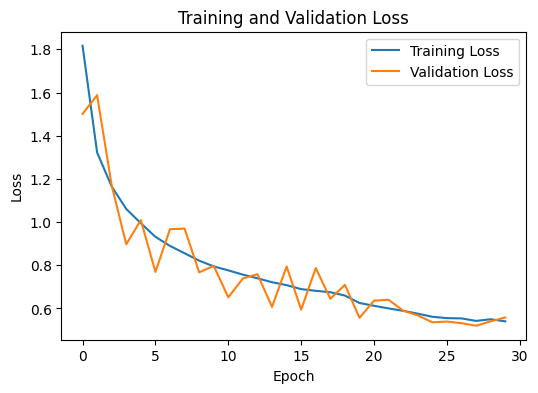

In [16]:
# Accuracy curves
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

# Loss curves
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


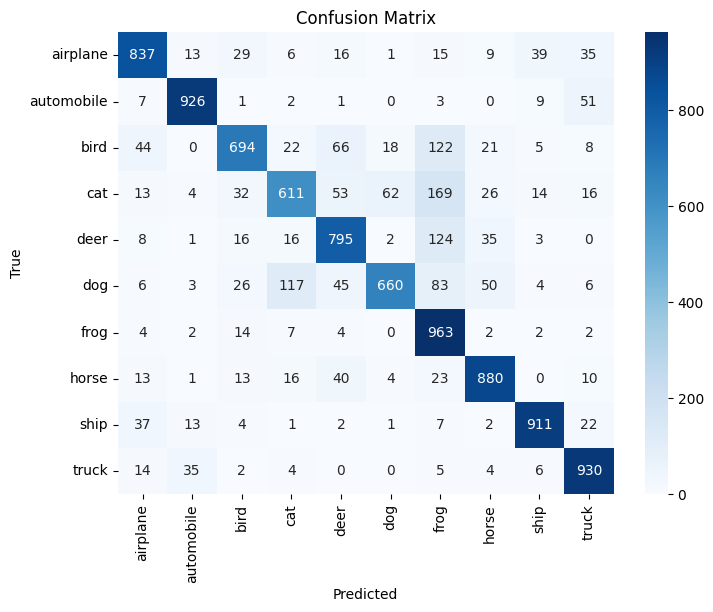

              precision    recall  f1-score   support

    airplane       0.85      0.84      0.84      1000
  automobile       0.93      0.93      0.93      1000
        bird       0.84      0.69      0.76      1000
         cat       0.76      0.61      0.68      1000
        deer       0.78      0.80      0.79      1000
         dog       0.88      0.66      0.76      1000
        frog       0.64      0.96      0.77      1000
       horse       0.86      0.88      0.87      1000
        ship       0.92      0.91      0.91      1000
       truck       0.86      0.93      0.89      1000

    accuracy                           0.82     10000
   macro avg       0.83      0.82      0.82     10000
weighted avg       0.83      0.82      0.82     10000



In [17]:
# Confusion matrix + classification report
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))


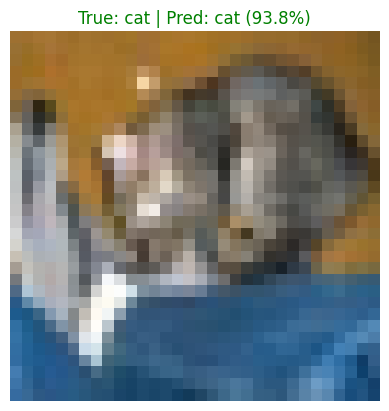

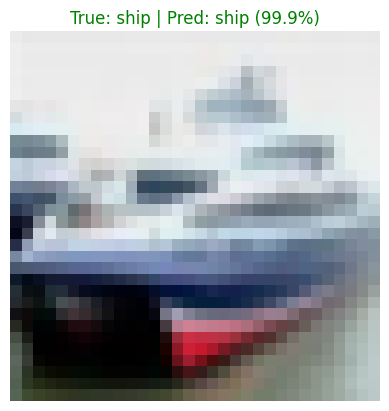

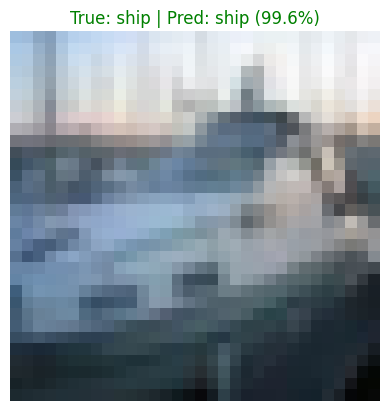

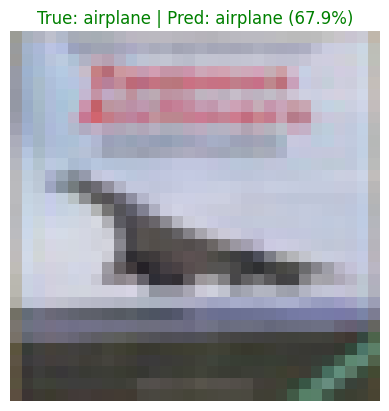

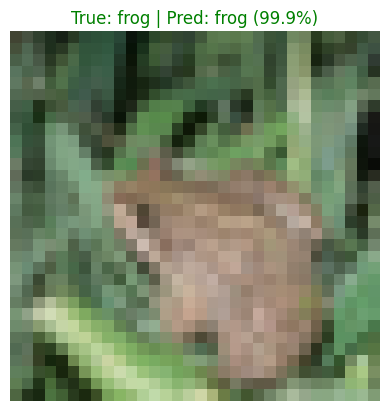

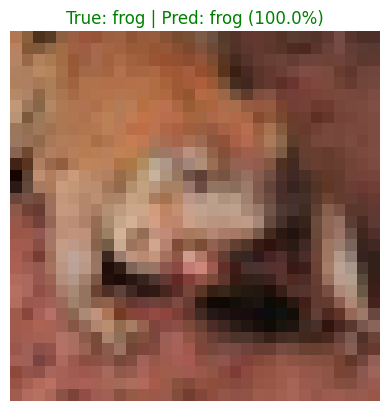

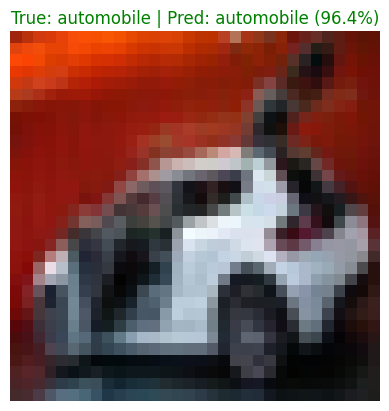

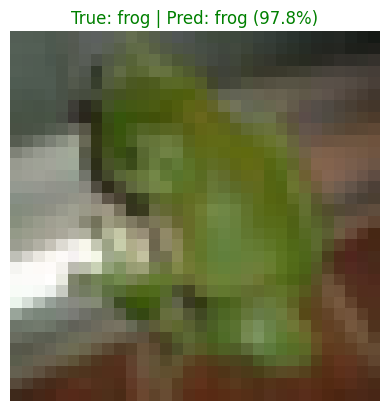

In [18]:
# Visualize a few sample predictions (fixed: labels are plain ints, not one-hot)
def plot_predictions(index):
    img = x_test[index]
    true_label = class_names[y_test[index]]
    pred_probs = model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_label = class_names[np.argmax(pred_probs)]
    confidence = np.max(pred_probs) * 100

    plt.imshow(img)
    color = "green" if pred_label == true_label else "red"
    plt.title(f"True: {true_label} | Pred: {pred_label} ({confidence:.1f}%)", color=color)
    plt.axis("off")
    plt.show()


for i in range(8):
    plot_predictions(i)


## 6. Save the Model for the Streamlit App

Save both the final trained model and the class name list, so the Streamlit app doesn't need to redefine them.

In [19]:
model.save("cifar10_cnn.keras")

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Saved cifar10_cnn.keras and class_names.json")
print("Copy both files next to streamlit_app.py, then run:")
print("    streamlit run streamlit_app.py")


Saved cifar10_cnn.keras and class_names.json
Copy both files next to streamlit_app.py, then run:
    streamlit run streamlit_app.py
